# AOI Change Sieve

This notebook answers one Phase 1 question:

Given an AOI from the photo-monitoring sites, where is the strongest baseline-to-endline disturbance, and what parts of it look like understory and canopy growth, understory decline, deforestation, or unexplained AlphaEarth change?

Time setup:
- Baseline: mean of `2018-2019`
- Endline maps: mean of `2023-2024`
- GIF years: baseline-to-current views for `2020-2024`


## Setup

The AOI is built from unique points in `db.json` with a `10 km` dissolved buffer.

Raster pulls are cached locally after first download.
- preferred cache: `/media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache`
- fallback cache: `./cache`

Display limits can be either fixed or percentile-based. Percentile mode is useful when a few extreme pixels wash out the rest of the map.


In [1]:
from pathlib import Path
import json
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib.colors import BoundaryNorm, ListedColormap
from shapely.geometry import Point

try:
    import ee
except Exception:
    ee = None

try:
    import geemap
except Exception:
    geemap = None

DATA_ROOT = Path('/media/desinotorious/T7 Shield/good-shepherd/notebooks/data')
CACHE_DIR = (DATA_ROOT / 'cache') if DATA_ROOT.exists() else Path('cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DB_PATH = Path('db.json')
LOCAL_METRIC_CRS = 'EPSG:32643'
AOI_BUFFER_KM = 10
MAP_SCALE_M = 120
GIF_FPS = 1

BASELINE_YEARS = [2018, 2019]
ENDLINE_YEARS = [2023, 2024]
GIF_YEARS = [2020, 2021, 2022, 2023, 2024]

# This is the gate for “AlphaEarth changed enough to matter.”
# Higher value: fewer AE-change pixels survive.
# Lower value: more AE-change pixels survive.
AE_CHANGE_THRESHOLD = 0.03

# Height change in meters that counts as meaningful GPW movement.
# Lower value: more AE pixels get explained by GPW.
GPW_CHANGE_THRESHOLD_M = 0.5

# Tree probability change that counts as meaningful Dynamic World movement.
# Lower value: more AE pixels get explained by DW.
DW_TREE_THRESHOLD = 0.10

# How much negative DW movement is still considered “stable enough” for the
# understory-decline class.
DW_STABLE_THRESHOLD = 0.05

# Display-only limits. These do not affect classification.
AE_CHANGE_MAX = 0.10
GPW_DELTA_RANGE_M = 10.0
DW_DELTA_RANGE = 0.50

# Display mode for static map color scaling.
# 'fixed': always use the display limits above.
# 'percentile': use AOI percentiles, capped by the display limits above.
DISPLAY_LIMIT_MODE = 'percentile'  # 'fixed' | 'percentile'

# GIFs use a single fixed scale per indicator across the entire GIF_YEARS period.
# This keeps color meaning stable from frame to frame so years can be compared visually.
GIF_DISPLAY_LIMIT_MODE = 'period_percentile'  # 'fixed' | 'period_percentile'
DISPLAY_PERCENTILE_LOW = 2
DISPLAY_PERCENTILE_HIGH = 98
DISPLAY_AE_VMAX_FLOOR = 1e-6
DISPLAY_SYMMETRIC_HALF_FLOOR = 1e-6


/home/desinotorious/src/github.com/bprashanth/good-shepherd/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
def initialize_earth_engine():
    if ee is None:
        raise RuntimeError('earthengine-api is not installed')
    ee.Initialize()
    print('Earth Engine initialized')


def image_to_cached_array(cache_name, image, region_geom, scale, bands):
    cache_path = CACHE_DIR / f'{cache_name}.npy'
    if cache_path.exists():
        print('loaded cache', cache_path)
        return np.load(cache_path)
    arr = geemap.ee_to_numpy(image, region=region_geom, scale=scale, bands=bands)
    np.save(cache_path, arr)
    print('saved cache', cache_path)
    return arr


def squeeze_band(arr):
    return np.squeeze(np.asarray(arr))


def display_ae_limits(arr, mode, vmax_fixed, pct_low, pct_high, vmax_cap, vmax_floor):
    arr = np.asarray(arr, dtype=float)
    valid = arr[np.isfinite(arr)]
    vmin = 0.0
    if valid.size == 0 or mode == 'fixed':
        return vmin, float(vmax_fixed)
    p_hi = float(np.percentile(valid, pct_high))
    vmax = min(max(p_hi, vmax_floor), float(vmax_cap))
    return vmin, vmax


def display_symmetric_limits(arr, mode, half_range_fixed, pct_low, pct_high, half_cap, half_floor):
    arr = np.asarray(arr, dtype=float)
    valid = arr[np.isfinite(arr)]
    if valid.size == 0 or mode == 'fixed':
        h = float(half_range_fixed)
        return -h, h
    lo = float(np.percentile(valid, pct_low))
    hi = float(np.percentile(valid, pct_high))
    half = max(abs(lo), abs(hi))
    half = min(max(half, half_floor), float(half_cap))
    return -half, half




def display_ae_limits_for_stack(arrays, mode, vmax_fixed, pct_high, vmax_cap, vmax_floor):
    valid_parts = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        valid = arr[np.isfinite(arr)]
        if valid.size:
            valid_parts.append(valid)
    if mode == 'fixed' or not valid_parts:
        return 0.0, float(vmax_fixed)
    merged = np.concatenate(valid_parts)
    vmax = min(max(float(np.percentile(merged, pct_high)), vmax_floor), float(vmax_cap))
    return 0.0, vmax


def display_symmetric_limits_for_stack(arrays, mode, half_range_fixed, pct_low, pct_high, half_cap, half_floor):
    valid_parts = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        valid = arr[np.isfinite(arr)]
        if valid.size:
            valid_parts.append(valid)
    if mode == 'fixed' or not valid_parts:
        h = float(half_range_fixed)
        return -h, h
    merged = np.concatenate(valid_parts)
    lo = float(np.percentile(merged, pct_low))
    hi = float(np.percentile(merged, pct_high))
    half = max(abs(lo), abs(hi))
    half = min(max(half, half_floor), float(half_cap))
    return -half, half



def mask_below_threshold(arr, threshold):
    arr = np.asarray(arr, dtype=float)
    return np.where(arr > threshold, arr, np.nan)


def make_threshold_cmap(base_cmap='inferno', background='#101014'):
    cmap = plt.colormaps[base_cmap].copy()
    cmap.set_bad(background)
    return cmap

def plot_continuous_map(arr, extent, title, cmap, vmin, vmax, cbar_label, legend_lines=None, sites_gdf=None, aoi_gdf=None):
    fig = plt.figure(figsize=(11, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 0.34], wspace=0.15)
    ax = fig.add_subplot(gs[0, 0])
    ax_leg = fig.add_subplot(gs[0, 1])

    im = ax.imshow(arr, origin='upper', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    if aoi_gdf is not None:
        aoi_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
    if sites_gdf is not None:
        ax.scatter(sites_gdf.geometry.x, sites_gdf.geometry.y, color='white', edgecolors='black', s=24, marker='x')
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(cbar_label)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax_leg.axis('off')
    legend_text = ['Monitoring sites: white x']
    if legend_lines:
        legend_text.extend(legend_lines)
    ax_leg.text(0.0, 1.0, '\n'.join(legend_text), va='top', ha='left', fontsize=10, wrap=True)
    plt.show()


def plot_class_map(class_arr, extent, class_labels, class_colors, title, legend_lines=None, sites_gdf=None, aoi_gdf=None):
    cmap = ListedColormap(class_colors)
    bounds = np.arange(len(class_labels) + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)
    fig = plt.figure(figsize=(11, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 0.34], wspace=0.15)
    ax = fig.add_subplot(gs[0, 0])
    ax_leg = fig.add_subplot(gs[0, 1])

    im = ax.imshow(class_arr, origin='upper', extent=extent, cmap=cmap, norm=norm)
    if aoi_gdf is not None:
        aoi_gdf.boundary.plot(ax=ax, color='white', linewidth=0.8)
    if sites_gdf is not None:
        ax.scatter(sites_gdf.geometry.x, sites_gdf.geometry.y, color='yellow', s=24, marker='x')
    cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(class_labels)), shrink=0.8)
    cbar.ax.set_yticklabels(class_labels)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax_leg.axis('off')
    legend_text = ['Monitoring sites: yellow x']
    if legend_lines:
        legend_text.extend(legend_lines)
    ax_leg.text(0.0, 1.0, '\n'.join(legend_text), va='top', ha='left', fontsize=10, wrap=True)
    plt.show()


def save_gif(frames, path, fps=GIF_FPS):
    if not frames:
        print('no frames for', path.name)
        return
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=int(1000 / fps), loop=0)
    print('saved', path)


def mask_abs_below_threshold(arr, threshold):
    arr = np.asarray(arr, dtype=float)
    return np.where(np.abs(arr) > threshold, arr, np.nan)


In [3]:
initialize_earth_engine()

records = json.loads(DB_PATH.read_text())
site_df = pd.DataFrame(records)[['siteId', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
site_df['geometry'] = site_df.apply(lambda r: Point(r['longitude'], r['latitude']), axis=1)
site_gdf = gpd.GeoDataFrame(site_df, geometry='geometry', crs='EPSG:4326')

site_metric = site_gdf.to_crs(LOCAL_METRIC_CRS)
aoi_metric = site_metric.buffer(AOI_BUFFER_KM * 1000).union_all()
aoi_gdf = gpd.GeoDataFrame({'name': ['monitoring_sites_10km_aoi']}, geometry=[aoi_metric], crs=LOCAL_METRIC_CRS).to_crs('EPSG:4326')
aoi_ee = geemap.geopandas_to_ee(aoi_gdf)

minx, miny, maxx, maxy = aoi_gdf.geometry.iloc[0].bounds
extent = [minx, maxx, miny, maxy]
aoi_region = ee.Geometry.Rectangle([minx, miny, maxx, maxy], proj='EPSG:4326', geodesic=False)

print('unique sites:', len(site_gdf))
print('AOI area km^2:', round(gpd.GeoSeries([aoi_metric], crs=LOCAL_METRIC_CRS).area.iloc[0] / 1_000_000, 2))
print('baseline years:', BASELINE_YEARS)
print('gif years:', GIF_YEARS)


Earth Engine initialized
unique sites: 29
AOI area km^2: 832.64
baseline years: [2018, 2019]
gif years: [2020, 2021, 2022, 2023, 2024]


## Dataset Build

We derive one baseline image and one endline image per dataset.

AlphaEarth:
- 64D annual embedding vectors
- change strength = `1 - cosine_similarity`

GPW:
- annual vegetation height in meters after scaling
- delta = `height(endline) - height(baseline)`

Dynamic World:
- annual mean tree probability
- delta = `tree_prob(endline) - tree_prob(baseline)`


In [4]:
ALPHAEARTH_DATASET = 'GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL'
GPW_HEIGHT_DATASET = 'projects/global-pasture-watch/assets/gsvh-30m/v1/short-veg-height_m'
DYNAMIC_WORLD_DATASET = 'GOOGLE/DYNAMICWORLD/V1'
AE_BANDS = [f'A{i:02d}' for i in range(64)]

alphaearth = ee.ImageCollection(ALPHAEARTH_DATASET).filterBounds(aoi_ee)
gpw_height = ee.ImageCollection(GPW_HEIGHT_DATASET).filterBounds(aoi_ee)
dynamic_world = ee.ImageCollection(DYNAMIC_WORLD_DATASET).filterBounds(aoi_ee)


def annotate_gpw_year(img):
    index_str = ee.String(img.get('system:index'))
    year_from_index = ee.Number.parse(index_str.slice(0, 4))
    year = ee.Algorithms.If(img.propertyNames().contains('year'), img.get('year'), year_from_index)
    return img.set('year', year)


gpw_height = gpw_height.map(annotate_gpw_year).sort('year')
gpw_height_scaled = gpw_height.map(
    lambda img: img.updateMask(img.gte(0)).multiply(0.1).rename('height').copyProperties(img, img.propertyNames())
)


def alphaearth_year_image(year):
    return alphaearth.filterDate(f'{year}-01-01', f'{year + 1}-01-01').filterBounds(aoi_ee).mosaic().select(AE_BANDS).set('year', year)


def gpw_year_image(year):
    return ee.Image(gpw_height_scaled.filter(ee.Filter.eq('year', year)).first()).select('height').set('year', year)


def dynamic_world_treeprob_year(year):
    yearly = dynamic_world.filterDate(f'{year}-01-01', f'{year + 1}-01-01').filterBounds(aoi_ee)
    return yearly.select('trees').mean().rename('tree_prob').set('year', year)


def alphaearth_change_from_baseline(end_years):
    baseline = ee.ImageCollection([alphaearth_year_image(y) for y in BASELINE_YEARS]).mean()
    endline = ee.ImageCollection([alphaearth_year_image(y) for y in end_years]).mean()
    base_arr = baseline.toArray()
    end_arr = endline.toArray()
    dot = base_arr.multiply(end_arr).arrayReduce(ee.Reducer.sum(), [0]).arrayGet([0])
    base_norm = base_arr.multiply(base_arr).arrayReduce(ee.Reducer.sum(), [0]).arrayGet([0]).sqrt()
    end_norm = end_arr.multiply(end_arr).arrayReduce(ee.Reducer.sum(), [0]).arrayGet([0]).sqrt()
    cosine = dot.divide(base_norm.multiply(end_norm)).rename('cosine_similarity')
    return ee.Image.constant(1).subtract(cosine).rename('ae_change_strength')


def gpw_delta_from_baseline(end_years):
    baseline = ee.ImageCollection([gpw_year_image(y) for y in BASELINE_YEARS]).mean().rename('height')
    endline = ee.ImageCollection([gpw_year_image(y) for y in end_years]).mean().rename('height')
    return endline.subtract(baseline).rename('gpw_height_delta_m')


def dw_delta_from_baseline(end_years):
    baseline = ee.ImageCollection([dynamic_world_treeprob_year(y) for y in BASELINE_YEARS]).mean().rename('tree_prob')
    endline = ee.ImageCollection([dynamic_world_treeprob_year(y) for y in end_years]).mean().rename('tree_prob')
    return endline.subtract(baseline).rename('dw_tree_prob_delta')


ae_change = alphaearth_change_from_baseline(ENDLINE_YEARS)
gpw_delta = gpw_delta_from_baseline(ENDLINE_YEARS)
dw_delta = dw_delta_from_baseline(ENDLINE_YEARS)


In [5]:
ae_change_arr = squeeze_band(image_to_cached_array('ae_change_strength_baseline_2018_2019_endline_2023_2024', ae_change, aoi_region, MAP_SCALE_M, ['ae_change_strength']))
gpw_delta_arr = squeeze_band(image_to_cached_array('gpw_height_delta_baseline_2018_2019_endline_2023_2024', gpw_delta, aoi_region, MAP_SCALE_M, ['gpw_height_delta_m']))
dw_delta_arr = squeeze_band(image_to_cached_array('dw_tree_prob_delta_baseline_2018_2019_endline_2023_2024', dw_delta, aoi_region, MAP_SCALE_M, ['dw_tree_prob_delta']))

ae_display_arr = mask_below_threshold(ae_change_arr, AE_CHANGE_THRESHOLD)
ae_vmin_raw, ae_vmax = display_ae_limits(
    ae_display_arr,
    DISPLAY_LIMIT_MODE,
    AE_CHANGE_MAX,
    DISPLAY_PERCENTILE_LOW,
    DISPLAY_PERCENTILE_HIGH,
    AE_CHANGE_MAX,
    DISPLAY_AE_VMAX_FLOOR,
)
ae_vmin = AE_CHANGE_THRESHOLD
ae_cmap = make_threshold_cmap('inferno', background='#101014')

gpw_vmin, gpw_vmax = display_symmetric_limits(
    gpw_delta_arr,
    DISPLAY_LIMIT_MODE,
    GPW_DELTA_RANGE_M,
    DISPLAY_PERCENTILE_LOW,
    DISPLAY_PERCENTILE_HIGH,
    GPW_DELTA_RANGE_M,
    DISPLAY_SYMMETRIC_HALF_FLOOR,
)
dw_vmin, dw_vmax = display_symmetric_limits(
    dw_delta_arr,
    DISPLAY_LIMIT_MODE,
    DW_DELTA_RANGE,
    DISPLAY_PERCENTILE_LOW,
    DISPLAY_PERCENTILE_HIGH,
    DW_DELTA_RANGE,
    DISPLAY_SYMMETRIC_HALF_FLOOR,
)

print('AE display limits:', ae_vmin, ae_vmax)
print('GPW display limits:', gpw_vmin, gpw_vmax)
print('DW display limits:', dw_vmin, dw_vmax)


loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/ae_change_strength_baseline_2018_2019_endline_2023_2024.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gpw_height_delta_baseline_2018_2019_endline_2023_2024.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/dw_tree_prob_delta_baseline_2018_2019_endline_2023_2024.npy
AE display limits: 0.03 0.07619740977345364
GPW display limits: -0.9499999999999993 0.9499999999999993
DW display limits: -0.11618744696424388 0.11618744696424388


## Map 1: AlphaEarth Change

Interpretation:
- metric: `1 - cosine_similarity`
- classification gate: `AE change > AE_CHANGE_THRESHOLD`
- display range: percentile-aware when enabled, capped by `AE_CHANGE_MAX`


/home/desinotorious/pip_tmp/ipykernel_1168302/332732007.py:102: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sites_gdf.geometry.x, sites_gdf.geometry.y, color='white', edgecolors='black', s=24, marker='x')


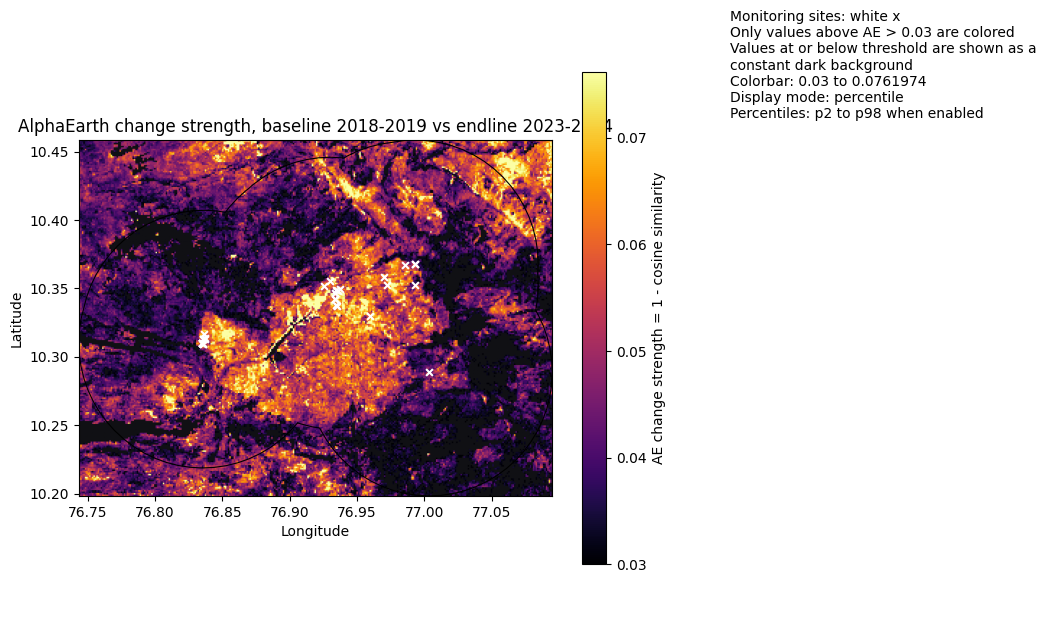

In [6]:
plot_continuous_map(
    ae_display_arr,
    extent=extent,
    title='AlphaEarth change strength, baseline 2018-2019 vs endline 2023-2024',
    cmap=ae_cmap,
    vmin=ae_vmin,
    vmax=ae_vmax,
    cbar_label='AE change strength = 1 - cosine similarity',
    legend_lines=[
        f'Only values above AE > {AE_CHANGE_THRESHOLD:g} are colored',
        'Values at or below threshold are shown as a constant dark background',
        f'Colorbar: {ae_vmin:g} to {ae_vmax:g}',
        f'Display mode: {DISPLAY_LIMIT_MODE}',
        f'Percentiles: p{DISPLAY_PERCENTILE_LOW} to p{DISPLAY_PERCENTILE_HIGH} when enabled',
    ],
    sites_gdf=site_gdf,
    aoi_gdf=aoi_gdf,
)


## Map 2: GPW Height Delta

Interpretation:
- metric: `height(endline) - height(baseline)`
- explanation gate: `|GPW delta| > GPW_CHANGE_THRESHOLD_M`
- display range: percentile-aware when enabled, capped by `GPW_DELTA_RANGE_M`


/home/desinotorious/pip_tmp/ipykernel_1168302/332732007.py:102: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sites_gdf.geometry.x, sites_gdf.geometry.y, color='white', edgecolors='black', s=24, marker='x')


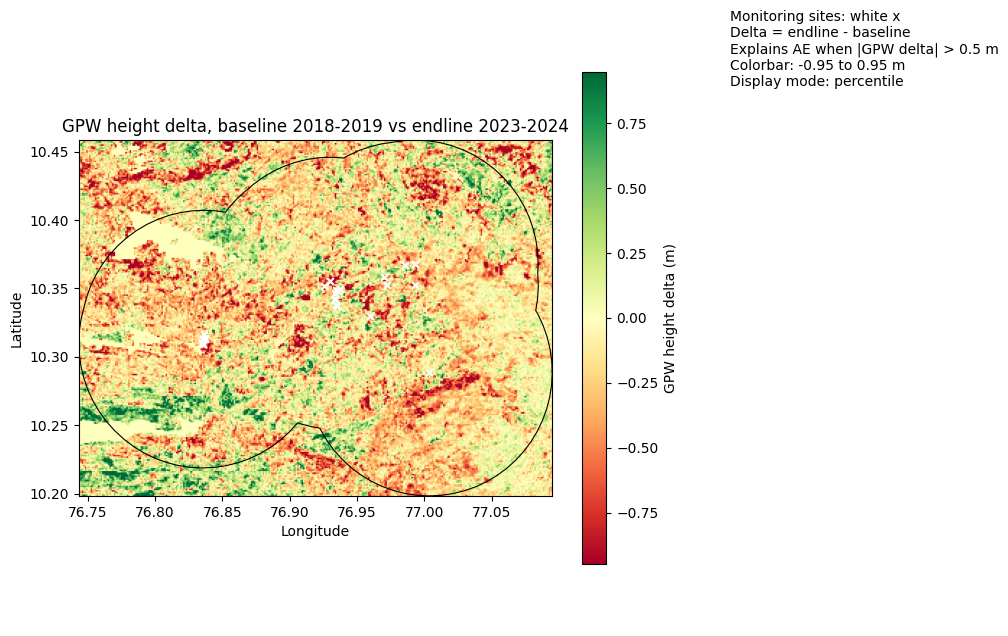

In [7]:
plot_continuous_map(
    gpw_delta_arr,
    extent=extent,
    title='GPW height delta, baseline 2018-2019 vs endline 2023-2024',
    cmap='RdYlGn',
    vmin=gpw_vmin,
    vmax=gpw_vmax,
    cbar_label='GPW height delta (m)',
    legend_lines=[
        'Delta = endline - baseline',
        f'Explains AE when |GPW delta| > {GPW_CHANGE_THRESHOLD_M:g} m',
        f'Colorbar: {gpw_vmin:g} to {gpw_vmax:g} m',
        f'Display mode: {DISPLAY_LIMIT_MODE}',
    ],
    sites_gdf=site_gdf,
    aoi_gdf=aoi_gdf,
)


## Map 3: Dynamic World Tree-Probability Delta

Interpretation:
- metric: `tree_prob(endline) - tree_prob(baseline)`
- explanation gate: `|DW delta| > DW_TREE_THRESHOLD`
- display range: percentile-aware when enabled, capped by `DW_DELTA_RANGE`


/home/desinotorious/pip_tmp/ipykernel_1168302/332732007.py:102: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sites_gdf.geometry.x, sites_gdf.geometry.y, color='white', edgecolors='black', s=24, marker='x')


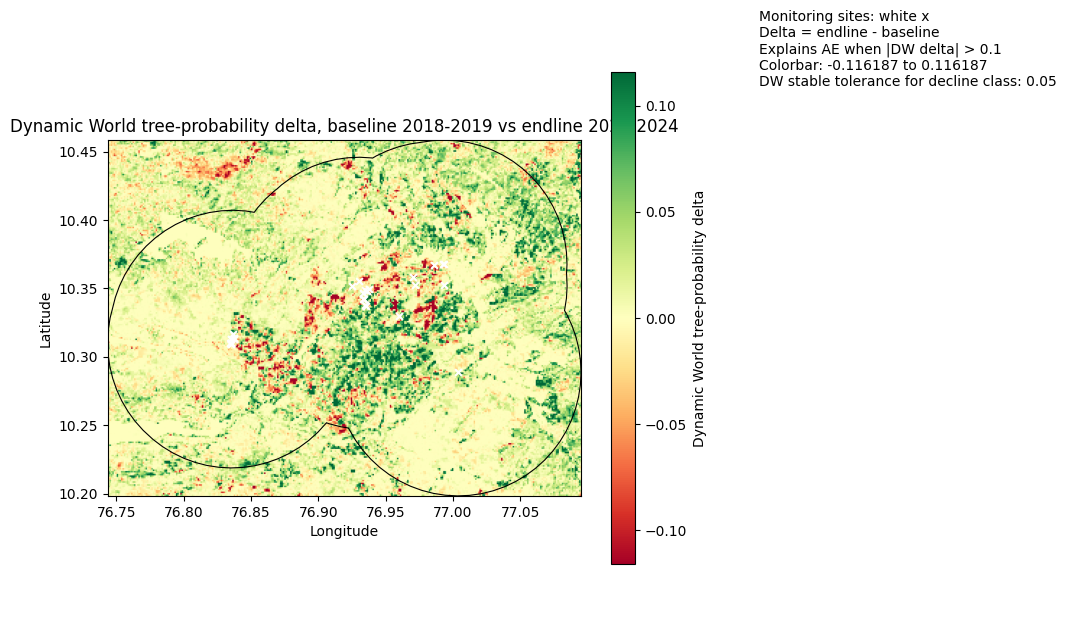

In [8]:
plot_continuous_map(
    dw_delta_arr,
    extent=extent,
    title='Dynamic World tree-probability delta, baseline 2018-2019 vs endline 2023-2024',
    cmap='RdYlGn',
    vmin=dw_vmin,
    vmax=dw_vmax,
    cbar_label='Dynamic World tree-probability delta',
    legend_lines=[
        'Delta = endline - baseline',
        f'Explains AE when |DW delta| > {DW_TREE_THRESHOLD:g}',
        f'Colorbar: {dw_vmin:g} to {dw_vmax:g}',
        f'DW stable tolerance for decline class: {DW_STABLE_THRESHOLD:g}',
    ],
    sites_gdf=site_gdf,
    aoi_gdf=aoi_gdf,
)


## Final Class Map

Definitions:
- `understory and canopy growth`: GPW increasing and Dynamic World increasing
- `understory decline`: GPW decreasing while Dynamic World is stable or increasing
- `deforestation`: GPW decreasing and Dynamic World decreasing
- `unexplained`: AlphaEarth changed strongly, but GPW and Dynamic World did not explain it


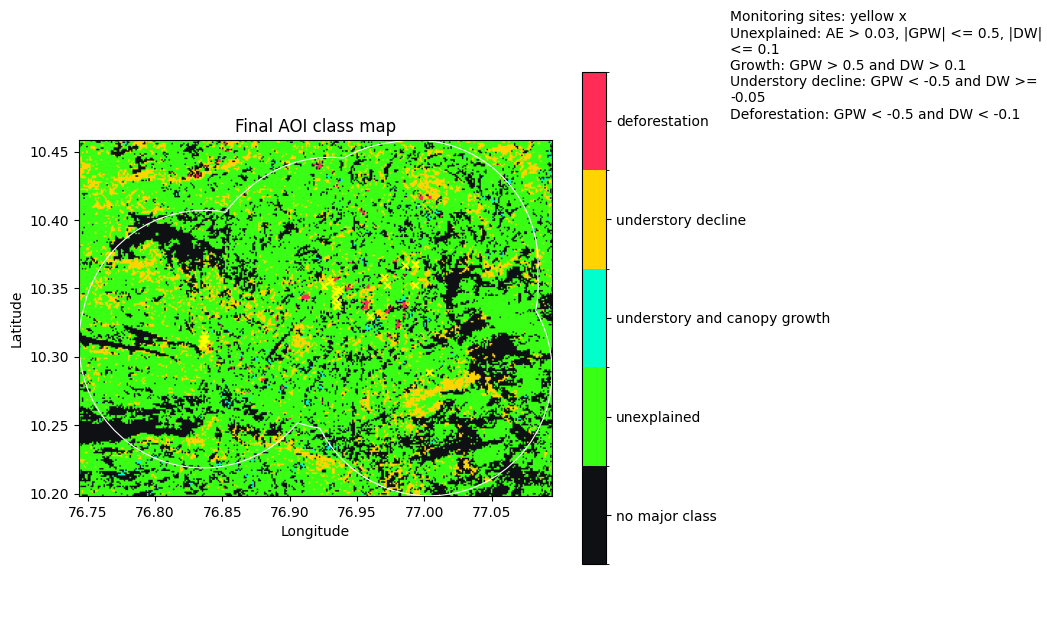

In [9]:
ae_big_change = ae_change_arr > AE_CHANGE_THRESHOLD
gpw_explains = np.abs(gpw_delta_arr) > GPW_CHANGE_THRESHOLD_M
dw_explains = np.abs(dw_delta_arr) > DW_TREE_THRESHOLD

unexplained = ae_big_change & (~gpw_explains) & (~dw_explains)
growth = (gpw_delta_arr > GPW_CHANGE_THRESHOLD_M) & (dw_delta_arr > DW_TREE_THRESHOLD)
understory_decline = (gpw_delta_arr < -GPW_CHANGE_THRESHOLD_M) & (dw_delta_arr >= -DW_STABLE_THRESHOLD)
deforestation = (gpw_delta_arr < -GPW_CHANGE_THRESHOLD_M) & (dw_delta_arr < -DW_TREE_THRESHOLD)

final_class = np.zeros_like(ae_change_arr, dtype=np.uint8)
final_class = np.where(unexplained, 1, final_class)
final_class = np.where(growth, 2, final_class)
final_class = np.where(understory_decline, 3, final_class)
final_class = np.where(deforestation, 4, final_class)

plot_class_map(
    final_class,
    extent=extent,
    class_labels=['no major class', 'unexplained', 'understory and canopy growth', 'understory decline', 'deforestation'],
    class_colors=['#0f1014', '#39ff14', '#00ffcc', '#ffd400', '#ff2d55'],
    title='Final AOI class map',
    legend_lines=[
        f'Unexplained: AE > {AE_CHANGE_THRESHOLD:g}, |GPW| <= {GPW_CHANGE_THRESHOLD_M:g}, |DW| <= {DW_TREE_THRESHOLD:g}',
        f'Growth: GPW > {GPW_CHANGE_THRESHOLD_M:g} and DW > {DW_TREE_THRESHOLD:g}',
        f'Understory decline: GPW < -{GPW_CHANGE_THRESHOLD_M:g} and DW >= -{DW_STABLE_THRESHOLD:g}',
        f'Deforestation: GPW < -{GPW_CHANGE_THRESHOLD_M:g} and DW < -{DW_TREE_THRESHOLD:g}',
    ],
    sites_gdf=site_gdf,
    aoi_gdf=aoi_gdf,
)


## Export Current Unexplained State

This cell saves the current Phase 1 state so follow-on exploratory notebooks do not need to recompute AlphaEarth, GPW, and Dynamic World from scratch.

Files written to the cache directory:
- `phase1_unexplained_mask.npy`
- `phase1_ae_change.npy`
- `phase1_gpw_delta.npy`
- `phase1_dw_delta.npy`
- `phase1_extent.json`
- `phase1_thresholds.json`


In [10]:
phase1_export_dir = CACHE_DIR / 'phase1_state'
phase1_export_dir.mkdir(parents=True, exist_ok=True)

np.save(phase1_export_dir / 'phase1_unexplained_mask.npy', unexplained.astype(np.uint8))
np.save(phase1_export_dir / 'phase1_ae_change.npy', ae_change_arr)
np.save(phase1_export_dir / 'phase1_gpw_delta.npy', gpw_delta_arr)
np.save(phase1_export_dir / 'phase1_dw_delta.npy', dw_delta_arr)

(Path(phase1_export_dir / 'phase1_extent.json')).write_text(json.dumps({
    'extent': extent,
    'baseline_years': BASELINE_YEARS,
    'endline_years': ENDLINE_YEARS,
}))
(Path(phase1_export_dir / 'phase1_thresholds.json')).write_text(json.dumps({
    'AE_CHANGE_THRESHOLD': AE_CHANGE_THRESHOLD,
    'GPW_CHANGE_THRESHOLD_M': GPW_CHANGE_THRESHOLD_M,
    'DW_TREE_THRESHOLD': DW_TREE_THRESHOLD,
    'DW_STABLE_THRESHOLD': DW_STABLE_THRESHOLD,
    'DISPLAY_LIMIT_MODE': DISPLAY_LIMIT_MODE,
    'DISPLAY_PERCENTILE_LOW': DISPLAY_PERCENTILE_LOW,
    'DISPLAY_PERCENTILE_HIGH': DISPLAY_PERCENTILE_HIGH,
}))

print('saved phase1 state to', phase1_export_dir)


saved phase1 state to /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/phase1_state


## GIFs: Baseline-to-Current Cumulative Change

These GIFs are not year-over-year diffs.

Each frame shows change relative to the same baseline mean (`2018-2019`):
- if GPW grows by `+1 m` and then another `+1 m`, the later frame becomes brighter green
- if it later drops by `0.5 m`, the frame becomes dimmer, reflecting net change from baseline

The GIF frames use the same percentile-aware display logic as the static maps.


loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_ae_change_2020.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_gpw_delta_2020.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_dw_delta_2020.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_ae_change_2021.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_gpw_delta_2021.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_dw_delta_2021.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_ae_change_2022.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_gpw_delta_2022.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_dw_delta_2022.npy
loaded cache /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/cache/gif_ae

/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


AE frames: 5
GPW frames: 5
DW frames: 5
AE gif scale: 0.03 0.1
GPW gif scale: -1.7999999999999998 1.7999999999999998
DW gif scale: -0.270180273987937 0.270180273987937


/home/desinotorious/pip_tmp/ipykernel_1168302/1000755366.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


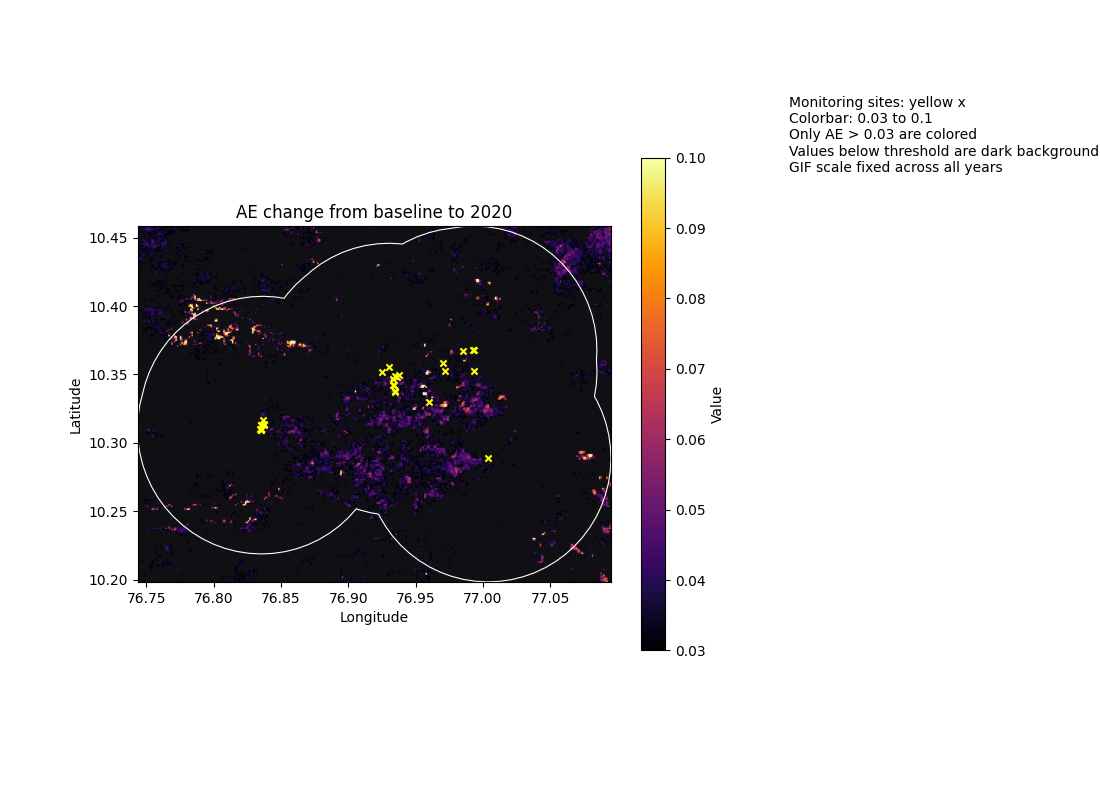

In [11]:
def build_cumulative_frame_from_array(arr, title, cmap, vmin, vmax, legend_lines):
    fig = plt.figure(figsize=(11, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 0.34], wspace=0.15)
    ax = fig.add_subplot(gs[0, 0])
    ax_leg = fig.add_subplot(gs[0, 1])

    im = ax.imshow(arr, origin='upper', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
    aoi_gdf.boundary.plot(ax=ax, color='white', linewidth=0.8)
    ax.scatter(site_gdf.geometry.x, site_gdf.geometry.y, color='yellow', s=20, marker='x')
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Value')
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax_leg.axis('off')
    ax_leg.text(0.0, 1.0, '\n'.join(['Monitoring sites: yellow x'] + legend_lines), va='top', ha='left', fontsize=10, wrap=True)

    fig.tight_layout()
    fig.canvas.draw()
    frame = Image.fromarray(np.asarray(fig.canvas.buffer_rgba())[..., :3])
    plt.close(fig)
    return frame


ae_year_arrays = []
ae_year_arrays_masked = []
gpw_year_arrays = []
gpw_year_arrays_masked = []
dw_year_arrays = []
dw_year_arrays_masked = []

for year in GIF_YEARS:
    ae_img = alphaearth_change_from_baseline([year])
    gpw_img = gpw_delta_from_baseline([year])
    dw_img = dw_delta_from_baseline([year])

    ae_arr = squeeze_band(image_to_cached_array(f'gif_ae_change_{year}', ae_img, aoi_region, MAP_SCALE_M, ['ae_change_strength']))
    gpw_arr = squeeze_band(image_to_cached_array(f'gif_gpw_delta_{year}', gpw_img, aoi_region, MAP_SCALE_M, ['gpw_height_delta_m']))
    dw_arr = squeeze_band(image_to_cached_array(f'gif_dw_delta_{year}', dw_img, aoi_region, MAP_SCALE_M, ['dw_tree_prob_delta']))

    ae_year_arrays.append(ae_arr)
    ae_year_arrays_masked.append(mask_below_threshold(ae_arr, AE_CHANGE_THRESHOLD))
    gpw_year_arrays.append(gpw_arr)
    gpw_year_arrays_masked.append(mask_abs_below_threshold(gpw_arr, GPW_CHANGE_THRESHOLD_M))
    dw_year_arrays.append(dw_arr)
    dw_year_arrays_masked.append(mask_abs_below_threshold(dw_arr, DW_TREE_THRESHOLD))

if GIF_DISPLAY_LIMIT_MODE == 'fixed':
    ae_gif_vmin, ae_gif_vmax = AE_CHANGE_THRESHOLD, AE_CHANGE_MAX
    gpw_gif_vmin, gpw_gif_vmax = -GPW_DELTA_RANGE_M, GPW_DELTA_RANGE_M
    dw_gif_vmin, dw_gif_vmax = -DW_DELTA_RANGE, DW_DELTA_RANGE
else:
    _, ae_gif_vmax = display_ae_limits_for_stack(ae_year_arrays_masked, 'period_percentile', AE_CHANGE_MAX, DISPLAY_PERCENTILE_HIGH, AE_CHANGE_MAX, DISPLAY_AE_VMAX_FLOOR)
    ae_gif_vmin = AE_CHANGE_THRESHOLD
    gpw_gif_vmin, gpw_gif_vmax = display_symmetric_limits_for_stack(gpw_year_arrays_masked, 'period_percentile', GPW_DELTA_RANGE_M, DISPLAY_PERCENTILE_LOW, DISPLAY_PERCENTILE_HIGH, GPW_DELTA_RANGE_M, DISPLAY_SYMMETRIC_HALF_FLOOR)
    dw_gif_vmin, dw_gif_vmax = display_symmetric_limits_for_stack(dw_year_arrays_masked, 'period_percentile', DW_DELTA_RANGE, DISPLAY_PERCENTILE_LOW, DISPLAY_PERCENTILE_HIGH, DW_DELTA_RANGE, DISPLAY_SYMMETRIC_HALF_FLOOR)

ae_frames = []
gpw_frames = []
dw_frames = []
gpw_cmap = make_threshold_cmap('RdYlGn', background='#101014')
dw_cmap = make_threshold_cmap('RdYlGn', background='#101014')

for year, ae_masked_arr, gpw_masked_arr, dw_masked_arr in zip(GIF_YEARS, ae_year_arrays_masked, gpw_year_arrays_masked, dw_year_arrays_masked):
    ae_frames.append(build_cumulative_frame_from_array(ae_masked_arr, f'AE change from baseline to {year}', ae_cmap, ae_gif_vmin, ae_gif_vmax, [f'Colorbar: {ae_gif_vmin:g} to {ae_gif_vmax:g}', f'Only AE > {AE_CHANGE_THRESHOLD:g} are colored', 'Values below threshold are dark background', 'GIF scale fixed across all years']))
    gpw_frames.append(build_cumulative_frame_from_array(gpw_masked_arr, f'GPW delta from baseline to {year}', gpw_cmap, gpw_gif_vmin, gpw_gif_vmax, [f'Colorbar: {gpw_gif_vmin:g} to {gpw_gif_vmax:g} m', f'Only |GPW| > {GPW_CHANGE_THRESHOLD_M:g} m are colored', 'Values inside threshold band are dark background', 'GIF scale fixed across all years']))
    dw_frames.append(build_cumulative_frame_from_array(dw_masked_arr, f'DW delta from baseline to {year}', dw_cmap, dw_gif_vmin, dw_gif_vmax, [f'Colorbar: {dw_gif_vmin:g} to {dw_gif_vmax:g}', f'Only |DW| > {DW_TREE_THRESHOLD:g} are colored', 'Values inside threshold band are dark background', 'GIF scale fixed across all years']))

print('AE frames:', len(ae_frames))
print('GPW frames:', len(gpw_frames))
print('DW frames:', len(dw_frames))
print('AE gif scale:', ae_gif_vmin, ae_gif_vmax)
print('GPW gif scale:', gpw_gif_vmin, gpw_gif_vmax)
print('DW gif scale:', dw_gif_vmin, dw_gif_vmax)
if ae_frames:
    display(ae_frames[0])


In [12]:
gif_dir = DATA_ROOT if DATA_ROOT.exists() else Path('.')
save_gif(ae_frames, gif_dir / 'ae_change_cumulative.gif')
save_gif(gpw_frames, gif_dir / 'gpw_change_cumulative.gif')
save_gif(dw_frames, gif_dir / 'dw_change_cumulative.gif')


saved /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/ae_change_cumulative.gif


saved /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/gpw_change_cumulative.gif


saved /media/desinotorious/T7 Shield/good-shepherd/notebooks/data/dw_change_cumulative.gif
